# Chapter 4 — Loss Functions

**The building block this notebook untangles:** Chapter 3's random-weight network
produced *some* output — but "some output" isn't useful unless we can say
*how wrong* it is, as a single number we can try to shrink. That number is the
**loss**. Everything from here on (Chapters 5–7) is about answering one
question: *which direction should each weight move to make the loss smaller?*

## Part 1 — Mean Squared Error (MSE)

The natural "how far off was I" measure: square the error (so overshooting and
undershooting both count as bad, and big errors are punished more than small
ones), then average over all samples.

$$\text{MSE} = \frac{1}{n}\sum_{i=1}^n (\hat{y}_i - y_i)^2$$

In [1]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.facecolor'] = 'white'

def mse(y_pred, y_true):
    return np.mean((y_pred - y_true) ** 2)

y_true = np.array([0, 1, 1, 0], dtype=float)

close_guess = np.array([0.1, 0.9, 0.8, 0.2])
bad_guess   = np.array([0.9, 0.1, 0.2, 0.9])

print("MSE, close guess:", round(mse(close_guess, y_true), 4))
print("MSE, bad guess:  ", round(mse(bad_guess, y_true), 4))

MSE, close guess: 0.025
MSE, bad guess:   0.7675


## Part 2 — Binary Cross-Entropy (BCE)

MSE works, but for classification (predicting a probability of class 1) it has a
weak point: it barely punishes a *confidently wrong* prediction. Cross-entropy
punishes confidence in the wrong answer much more harshly — which is exactly the
signal we want when the output is a probability.

$$\text{BCE} = -\frac{1}{n}\sum_{i=1}^n \Big[ y_i \log(\hat{y}_i) + (1-y_i)\log(1-\hat{y}_i) \Big]$$

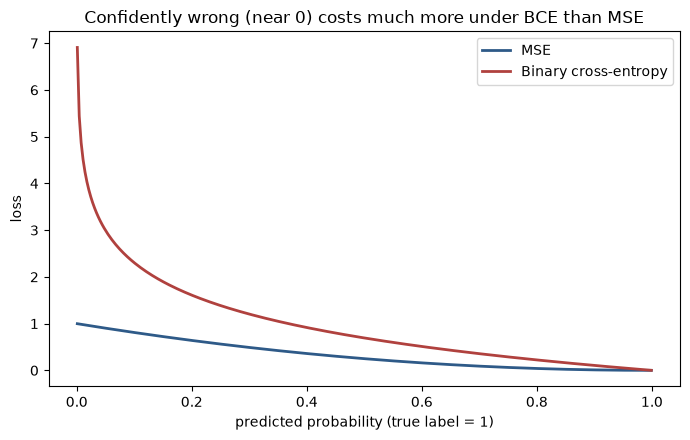

In [2]:
def binary_cross_entropy(y_pred, y_true, eps=1e-12):
    y_pred = np.clip(y_pred, eps, 1 - eps)   # avoid log(0)
    return -np.mean(y_true * np.log(y_pred) + (1 - y_true) * np.log(1 - y_pred))

# One sample, target = 1. Sweep the prediction from "confidently wrong" to "confidently right".
preds = np.linspace(0.001, 0.999, 300)
target = 1.0

mse_curve = (preds - target) ** 2
bce_curve = -(target * np.log(preds) + (1 - target) * np.log(1 - preds))

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(preds, mse_curve, label='MSE', color='#2E5A88', linewidth=2)
ax.plot(preds, bce_curve, label='Binary cross-entropy', color='#B0413E', linewidth=2)
ax.set_xlabel('predicted probability (true label = 1)')
ax.set_ylabel('loss')
ax.set_title('Confidently wrong (near 0) costs much more under BCE than MSE')
ax.legend()
plt.tight_layout()
plt.show()

Near `prediction ≈ 0` (confidently and *wrongly* certain the answer is 0, when
the true label is 1), BCE shoots toward infinity while MSE plateaus around `1.0`.
That's why BCE is the standard loss for binary classification, and MSE is
typically reserved for regression (predicting continuous numbers, not
probabilities).

## Part 3 — Scoring Chapter 3's random network

Chapter 3 left us with a network whose weights were pure noise. Let's put a
number on exactly how bad that was.

In [3]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def relu(z):
    return np.maximum(0, z)

def forward(X, W1, b1, W2, b2):
    Z1 = X @ W1 + b1
    A1 = relu(Z1)
    Z2 = A1 @ W2 + b2
    A2 = sigmoid(Z2)
    return Z1, A1, Z2, A2

X_xor = np.array([[0, 0], [0, 1], [1, 0], [1, 1]], dtype=float)
y_xor = np.array([0, 1, 1, 0], dtype=float)

rng = np.random.default_rng(7)
W1 = rng.normal(scale=1.0, size=(2, 4))
b1 = np.zeros(4)
W2 = rng.normal(scale=1.0, size=(4, 1))
b2 = np.zeros(1)

_, _, _, A2 = forward(X_xor, W1, b1, W2, b2)
y_pred = A2.ravel()

print("Predictions:", np.round(y_pred, 4))
print("Targets:    ", y_xor)
print("BCE loss:   ", round(binary_cross_entropy(y_pred, y_xor), 4))

Predictions: [0.5    0.6243 0.4536 0.54  ]
Targets:     [0. 1. 1. 0.]
BCE loss:    0.6828


## Part 4 — Loss as a landscape

Zoom out from one prediction to the whole *space* of possible weights. Freeze
every weight except one, sweep it across a range, and plot the loss at each
value. This "loss landscape" is the surface Chapters 5–6 will learn to descend.

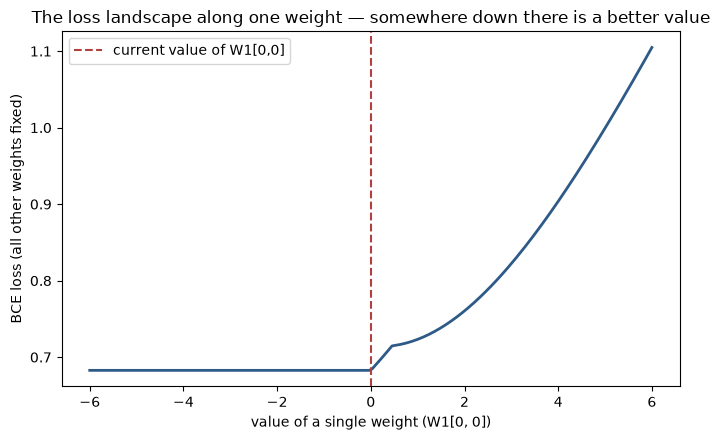

In [4]:
w_range = np.linspace(-6, 6, 200)
losses = []
for w1_00 in w_range:
    W1_trial = W1.copy()
    W1_trial[0, 0] = w1_00
    _, _, _, A2_trial = forward(X_xor, W1_trial, b1, W2, b2)
    losses.append(binary_cross_entropy(A2_trial.ravel(), y_xor))

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(w_range, losses, color='#2E5A88', linewidth=2)
ax.axvline(W1[0, 0], color='#B0413E', linestyle='--', label='current value of W1[0,0]')
ax.set_xlabel('value of a single weight (W1[0, 0])')
ax.set_ylabel('BCE loss (all other weights fixed)')
ax.set_title('The loss landscape along one weight — somewhere down there is a better value')
ax.legend()
plt.tight_layout()
plt.show()

## Recap

The loss compresses "how good are these weights" into one number. MSE for
regression, cross-entropy for classification. The loss landscape plot makes the
next step obvious: if we know the *slope* of this curve at our current weight,
we know which direction lowers the loss. That slope is the gradient —
Chapter 5's backpropagation is how we compute it for every weight in the
network at once.

**Next:** [Chapter 5 — Backpropagation](05_backpropagation.ipynb)